In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [42]:
movies = pd.read_csv(r"C:\Users\user\Downloads\imdb_top_1000.csv")

movies.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [43]:
#COLUMN NAMES
movies.columns

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')

In [44]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


In [45]:
#BASIC DETAILS
movies.describe()

,IMDB_Rating,Meta_score,No_of_Votes
count,1000.000000,843.000000,1.000000e+03
mean,7.949300,77.971530,2.736929e+05
std,0.275491,12.376099,3.273727e+05
min,7.600000,28.000000,2.508800e+04
25%,7.700000,70.000000,5.552625e+04
50%,7.900000,79.000000,1.385485e+05
75%,8.100000,87.000000,3.741612e+05
max,9.300000,100.000000,2.343110e+06


In [46]:
#CHECKING NULL VALUES
movies.isnull().sum()

Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64

In [47]:
#DROPPING DUPLICATE MOVIES
movies.drop_duplicates(inplace=True)

In [48]:
#FILLING NULL VALUES
movies['Certificate'] = movies['Certificate'].fillna('Unknown')

In [49]:
movies.columns

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')

In [50]:
#DROPPING UN-NECESSARY COLUMNS
movies.drop(columns=['Gross', 'Meta_score'], inplace=True)

In [51]:
movies.columns


Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Director', 'Star1',
       'Star2', 'Star3', 'Star4', 'No_of_Votes'],
      dtype='object')

In [52]:
movies.shape

(1000, 14)

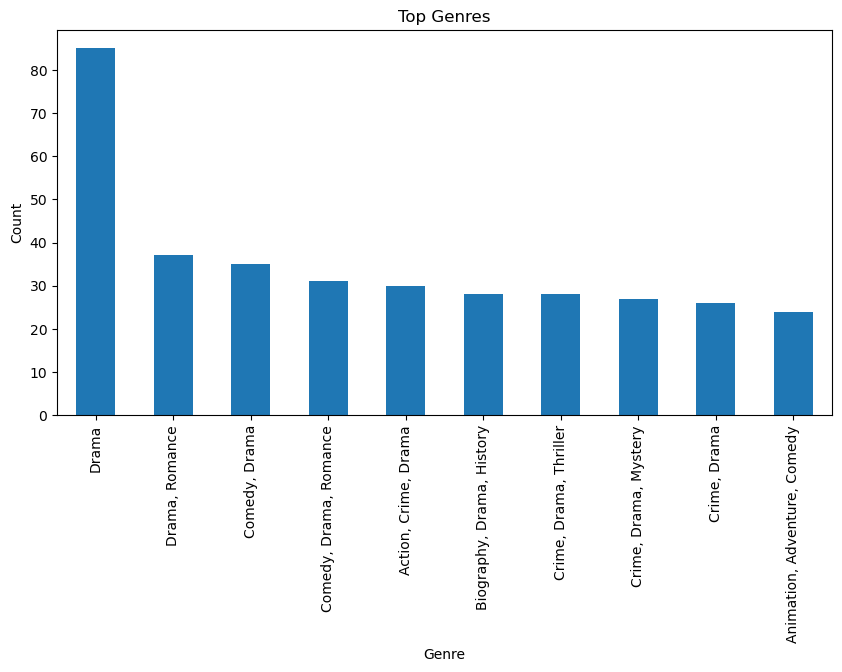

In [53]:
#Top 10 Genres Visualization
genre_counts = movies['Genre'].value_counts().head(10)

plt.figure(figsize=(10,5))
genre_counts.plot(kind='bar')

plt.title("Top Genres")
plt.xlabel("Genre")
plt.ylabel("Count")

plt.show()

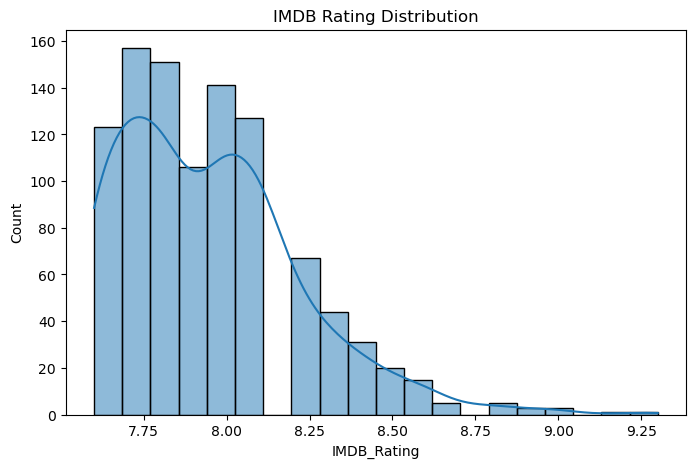

In [54]:
#IMDB Rating Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    movies['IMDB_Rating'],
    bins=20,
    kde=True
)

plt.title("IMDB Rating Distribution")

plt.show()

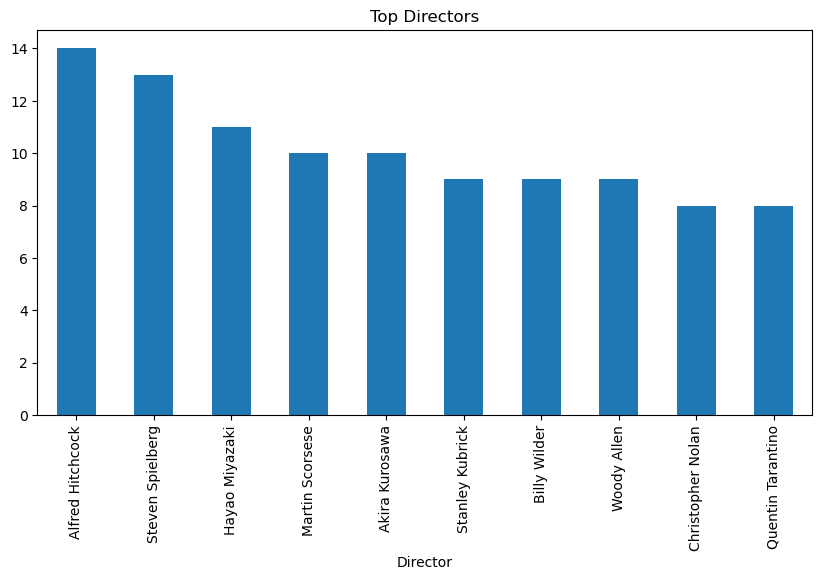

In [55]:
#FINDING TOP DIRECTORS
top_directors = movies['Director'].value_counts().head(10)

plt.figure(figsize=(10,5))

top_directors.plot(kind='bar')

plt.title("Top Directors")

plt.show()

In [56]:
#CREATING TAGS
movies['tags'] = (
    movies['Genre'].astype(str)
    + " " +
    movies['Director'].astype(str)
    + " " +
    movies['Star1'].astype(str)
    + " " +
    movies['Star2'].astype(str)
    + " " +
    movies['Star3'].astype(str)
    + " " +
    movies['Overview'].astype(str)
)

In [57]:
#CHECKING TAGS
movies[['Series_Title','tags']].head()

,Series_Title,tags
0,The Shawshank Redemption,Drama Frank Darabont Tim Robbins Morgan Freema...
1,The Godfather,"Crime, Drama Francis Ford Coppola Marlon Brand..."
2,The Dark Knight,"Action, Crime, Drama Christopher Nolan Christi..."
3,The Godfather: Part II,"Crime, Drama Francis Ford Coppola Al Pacino Ro..."
4,12 Angry Men,"Crime, Drama Sidney Lumet Henry Fonda Lee J. C..."


In [58]:
#VECTORIZATION
cv = CountVectorizer(
    max_features=5000,
    stop_words='english'
)

vectors = cv.fit_transform(
    movies['tags']
).toarray()

In [59]:
vectors.shape

(1000, 5000)

In [60]:
#COSINE SIMILARITY
similarity = cosine_similarity(vectors)

similarity.shape

(1000, 1000)

In [61]:
#RECOMMENDATION FUNCTION
import difflib

def recommend(movie):

    # clean input
    movie = movie.lower().strip()

    # clean dataset titles
    titles = movies['Series_Title'].str.lower().str.strip().tolist()

    #(handles spelling mistakes)
    match = difflib.get_close_matches(movie, titles, n=1, cutoff=0.6)

    if not match:
        print("Movie not found. Please check the name.")
        return

    best_match = match[0]

    # get index of matched movie
    movie_index = movies[
        movies['Series_Title'].str.lower().str.strip() == best_match
    ].index[0]

    # similarity scores
    distances = similarity[movie_index]

    # top 5 similar movies
    movie_list = sorted(
        list(enumerate(distances)),
        reverse=True,
        key=lambda x: x[1]
    )[1:6]

    print("\nRecommendations for:", movies.iloc[movie_index].Series_Title)
    print("-" * 40)

    for i in movie_list:
        print(movies.iloc[i[0]].Series_Title)

In [64]:
#CALLING THE FUNCTION
recommend("SHUTTER ISLAND")



Recommendations for: Shutter Island
----------------------------------------
The Departed
The Wolf of Wall Street
M - Eine Stadt sucht einen Mörder
Memento
Blood Diamond
